In [1]:
import os
import json
import gzip
import pandas as pd
import numpy as np

import scipy.sparse as spsparse
import scipy.stats as spstats

from statsmodels.stats.multitest import multipletests as holm
import statsmodels.api as sm

import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms

import seaborn as sns

# Correlation with capacity and goverment index

In [36]:
filename_suffix='noselfauthor_bootstrap'

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')


data2017=dfself_vars[dfself_vars['Year']==2019]



indexdf=pd.read_csv('CountryData/capacity_gov_index.csv')

country_codes=pd.read_csv('CountryData/Gravity_csv_V202211/Countries_V202211.csv')
country_codes['iso2']=country_codes['iso2'].str.strip()
country_codes['iso3']=country_codes['iso3'].str.strip()
country_dict = dict(zip(country_codes['iso3'], country_codes['iso2']))


indexdf['country_code'] = indexdf['country_code'].map(country_dict)


indexdf_sub=indexdf[['country_code','cap_ind', 'gov_ind',
       'interaction_term', 'cap_sum_index', 'gov_sum_index',
       'cap_sum_index_alt', 'int_sum_term']]

data2017=data2017.merge(indexdf_sub,how='left', left_on='Country', right_on='country_code')

In [37]:
data2017['FracTop'].corr(data2017['cap_ind']),data2017['FracTop'].corr(data2017['logzscore']),

(0.35865897421880777, 0.35544784319286005)

In [38]:
# indexsum=pd.read_csv('CountryData/panel_sum_index_1990_2020.csv')
# indexsum.sort_values(by=['country_code','date'], inplace=True)
# indexsum=indexsum[['country_code','date','cap_sum_index', 'gov_sum_index',]]
# indexsum['country_code']=indexsum['country_code'].str.strip()
# indexsum['country_code'] = indexsum['country_code'].map(country_dict)

# data_index=dfself_vars.merge(indexsum, how='left',left_on=['Country','Year'], right_on=['country_code','date'])

In [39]:
data_index

,CitingCountry,Year,Country,AUC,N,STD,zscore,pvalue,significant,NumPub,...,disruption_mean,disrupt_top10_rate,disrupt_top5_rate,novel_pct10_rate_norm,hit_rate,hit_rate_scinet,country_code,date_y,cap_sum_index_y,gov_sum_index_y
0,AE,2005,AE,0.522007,57,0.019949,1.103144,1.349823e-01,False,805,...,0.004254,0.245540,0.102379,0.963190,0.082885,0.107570,AE,2005.0,50.552603,0.896
1,AE,2006,AE,0.535211,73,0.018011,1.954971,2.529327e-02,False,920,...,0.003256,0.276025,0.108814,1.075293,0.091996,0.110084,AE,2006.0,51.402623,0.840
2,AE,2007,AE,0.520049,66,0.019021,1.054066,1.459264e-01,False,991,...,0.002334,0.297686,0.119762,0.917841,0.107114,0.115356,AE,2007.0,51.697167,1.091
3,AE,2008,AE,0.526826,88,0.014461,1.854976,3.179984e-02,False,1155,...,0.002940,0.307692,0.116653,0.906043,0.105720,0.111984,AE,2008.0,52.308992,0.833
4,AE,2009,AE,0.565627,95,0.017381,3.775801,7.974724e-05,True,1258,...,0.002917,0.286957,0.113540,0.765525,0.117801,0.125808,AE,2009.0,53.378501,0.766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,ZW,2015,ZW,0.546007,146,0.011815,3.893942,4.931419e-05,True,1125,...,0.004065,0.359420,0.137198,1.204324,0.088235,0.077502,ZW,2015.0,41.574471,-2.855
2497,ZW,2016,ZW,0.579939,176,0.012825,6.232976,2.288284e-10,True,994,...,0.002948,0.379349,0.139526,1.183107,0.109721,0.108581,ZW,2016.0,43.637746,-2.881
2498,ZW,2017,ZW,0.566057,230,0.009910,6.665361,1.320079e-11,True,1207,...,0.006163,0.324755,0.137255,1.269811,0.111916,0.109104,ZW,2017.0,44.017311,-2.869
2499,ZW,2018,ZW,0.567694,195,0.012286,5.510086,1.793293e-08,True,1199,...,0.001578,0.327426,0.125263,1.130124,0.093502,0.086774,ZW,2018.0,44.888951,-2.732


# Figure S9: Correlation between research capacity and citation self-preference.

In [40]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   
colours=['#8D95A0','#2171b5','#DA6437','#E18683']

def correlation_plot(data, x,y, ax,xlabel,ylabel, color):

    #ax=sns.regplot(ax=ax, data=data, x=x,y=y, s=50)

    ax=sns.regplot(ax=ax,data=data, y=y,x=x,
               scatter_kws={'color': colours[0], 's':70, 'alpha':0.8, 
                            'edgecolor': 'w', 'linewidths': 0.9},  # grey dots
    line_kws={'color': colours[color], 'lw':3, 'alpha':0.8}, 
            #x_bins=20 
           )

    
    countries = ['US','GB', 'DE', 'FR', 'JP', 'NL', 'CH', 'CN', 'IN', 'BR', 'SA','IR']
      
    ax.set_ylabel(ylabel, fontsize=25)
    ax.set_xlabel(xlabel, fontsize=25)
    ax.tick_params(labelsize=23, direction='out', length=4, width=2) 
    
    from scipy.stats import pearsonr
    
    df_clean = data[['logzscore', y,'FracInternationalAuthors']].dropna()
    
    # Compute correlation
    r, p = pearsonr(df_clean[x], df_clean[y])
    

    ax.text(
        0.1, 1, 
        f"Pearson's $r$ = {r:.3f} \n p = {p:.3f}",
        transform=ax.transAxes,
        fontsize=20,
        ha='left',
        va='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.)
    )

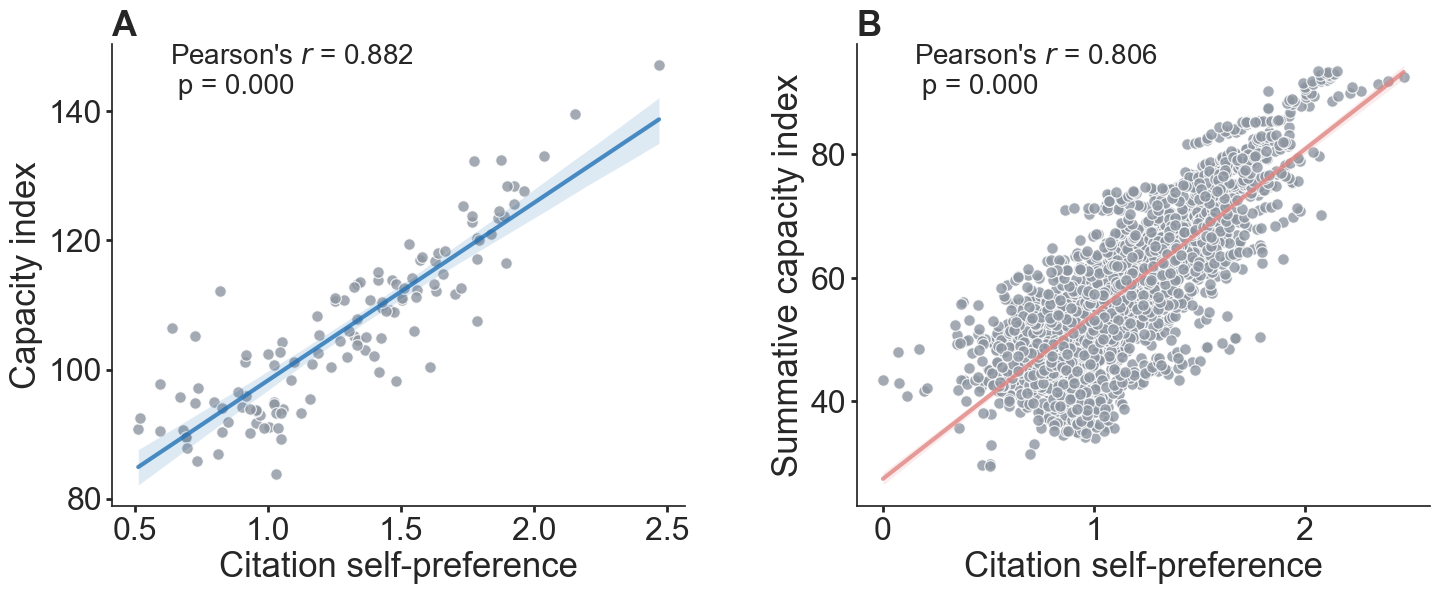

In [41]:
layout = [
    ["A", "B",],
    
]

fig, axes = plt.subplot_mosaic(layout, figsize=(17,6), 
                                  gridspec_kw={'height_ratios': [1,],  "hspace": 0.2,  "wspace": 0.3},
                                 constrained_layout=False, )
for label, ax in axes.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=25, )  # Title at the upper left corner
    ax.title.set_x(-10)

correlation_plot(data2017, 'logzscore','cap_ind', axes['A'], 'Citation self-preference','Capacity index',1)

correlation_plot(dfself_vars, 'logzscore','cap_sum_index',  axes['B'],'Citation self-preference', 'Summative capacity index',3)


plt.savefig(f"FigureSelfCitation/NewData/SI_capacityVSzscore_{filename_suffix}.pdf", bbox_inches='tight')

# Table S4: Correlation between citation self-preference and research capacity indices.

In [45]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

datac1 = data2017.dropna(subset=['logzscore', 'cap_ind'])
datac2 = dfself_vars.dropna(subset=['logzscore', 'cap_sum_index', 'Country', 'Year'])

for i in ['logzscore', 'cap_ind']:
    datac1[i] = (datac1[i] - datac1[i].mean()) / datac1[i].std()

for i in ['logzscore', 'cap_sum_index']:
    datac2[i] = (datac2[i] - datac2[i].mean()) / datac2[i].std()

m0 = smf.ols(formula='cap_ind ~ logzscore', data=datac1).fit()
m1 = smf.ols(formula='cap_sum_index ~ logzscore', data=datac2).fit()
m2 = smf.ols(formula='cap_sum_index ~ logzscore + C(Country) + C(Year)', data=datac2).fit(
     cov_type='cluster', cov_kwds={'groups': datac2['Country']})

stargazer = Stargazer([m0, m1, m2])
stargazer.covariate_order(['logzscore'])
stargazer.rename_covariates({'logzscore': 'Citation self-preference'})

# dependent variable labels per model
stargazer.dependent_variable_name('Research capacity')
stargazer.custom_columns(
    ['Composite index', 'Summative capacity index', 'Summative capacity index'],
    [1, 1, 1]
)


# caption and label
stargazer.title('Validation of citation self-preference as a proxy for national scientific capacity')
stargazer.add_line('Country FE', ['No', 'No', 'Yes'])
stargazer.add_line('Year FE',    ['No', 'No', 'Yes'])
stargazer.add_line('Clustered SE', ['No', 'No', 'Country'])

latex_str = stargazer.render_latex()

# inject label manually since stargazer does not support it natively
latex_str = latex_str.replace(
    '\\end{table}',
    '\\label{tab:SI_validation_capacity}\n\\end{table}'
)

print(latex_str)

\begin{table}[!htbp] \centering
  \caption{Validation of citation self-preference as a proxy for national scientific capacity}
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & \multicolumn{1}{c}{Composite index} & \multicolumn{1}{c}{Summative capacity index} & \multicolumn{1}{c}{Summative capacity index}  \\
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 Citation self-preference & 0.882$^{***}$ & 0.806$^{***}$ & 0.235$^{***}$ \\
& (0.043) & (0.012) & (0.027) \\
 Country FE & No & No & Yes \\
 Year FE & No & No & Yes \\
 Clustered SE & No & No & Country \\
\hline \\[-1.8ex]
 Observations & 123 & 2411 & 2411 \\
 $R^2$ & 0.777 & 0.650 & 0.990 \\
 Adjusted $R^2$ & 0.775 & 0.650 & 0.989 \\
 Residual Std. Error & 0.474 (df=121) & 0.592 (df=2409) & 0.106 (df=2254) \\
 F Statistic & 422.077$^{***}$ (df=1; 121) & 4468.950$^{***}$ (df=1; 2409) & 4056.835$^{***}$ (df=156; 2254) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{3}{r}{$^{*}$p$<$0

/var/folders/pw/3c9bpx2x49j17_0h64t91zgr0000gr/T/ipykernel_38103/787849934.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datac1[i] = (datac1[i] - datac1[i].mean()) / datac1[i].std()
/var/folders/pw/3c9bpx2x49j17_0h64t91zgr0000gr/T/ipykernel_38103/787849934.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datac2[i] = (datac2[i] - datac2[i].mean()) / datac2[i].std()
/Users/psp2nq/anaconda3/envs/bigdata/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constrain

# Table S5: Regression estimates of scientific quality on capacity indices.

In [53]:
filename_suffix='noselfauthor_bootstrap'

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')


data2017=dfself_vars[dfself_vars['Year']==2019]


indexdf=pd.read_csv('CountryData/capacity_gov_index.csv')

country_codes=pd.read_csv('CountryData/Gravity_csv_V202211/Countries_V202211.csv')
country_codes['iso2']=country_codes['iso2'].str.strip()
country_codes['iso3']=country_codes['iso3'].str.strip()
country_dict = dict(zip(country_codes['iso3'], country_codes['iso2']))


indexdf['country_code'] = indexdf['country_code'].map(country_dict)


indexdf_sub=indexdf[['country_code','cap_ind', 'gov_ind',
       'interaction_term', 'cap_sum_index', 'gov_sum_index',
       'cap_sum_index_alt', 'int_sum_term']]

data2017=data2017.merge(indexdf_sub,how='left', left_on='Country', right_on='country_code')

In [54]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
data2017[[ 'cap_ind']] = scaler.fit_transform(data2017[['cap_ind']])
dfself_vars[[ 'cap_sum_index']] = scaler.fit_transform(dfself_vars[['cap_sum_index']])

data2017['NResearchers']=np.log10(data2017['NResearchers'])
dfself_vars['NResearchers']=np.log10(dfself_vars['NResearchers'])

for i in ['normalized_frac_top','FracInternationalAuthors', 'NResearchers','RND_per','GDP_PCAP' ]:
    data2017[[ i]] = scaler.fit_transform(data2017[[i]])
    dfself_vars[[ i]] = scaler.fit_transform(dfself_vars[[i]])


In [57]:
stargazer = Stargazer([m1, m2, m3, m11, m22, m33])

stargazer.covariate_order([
    'cap_ind', 'cap_sum_index',
    'FracInternationalAuthors',
    'FracInternationalAuthors:cap_ind',
    'FracInternationalAuthors:cap_sum_index',
    'GDP_PCAP', 'RND_per', 'NResearchers'
])

stargazer.rename_covariates({
    'cap_ind'                          : 'Capacity index',
    'cap_sum_index'                    : 'Capacity summative index',
    'FracInternationalAuthors'         : 'International collaboration',
    'FracInternationalAuthors:cap_ind' : 'Intl. collaboration $\\times$ Capacity index',
    'FracInternationalAuthors:cap_sum_index': 'Intl. collaboration $\\times$ Capacity summative index',
    'GDP_PCAP'                         : 'GDP per capita',
    'RND_per'                          : 'R\\&D as \\% of GDP',
    'NResearchers'                     : 'No. researchers per million'
})

stargazer.title('Regression estimates of top journal rate on capacity indices.')
stargazer.dependent_variable_name('Top journal rate')

stargazer.add_line('Country FE',   ['No', 'No', 'No', 'Yes', 'Yes', 'Yes'])
stargazer.add_line('Year FE',      ['No', 'No', 'No', 'Yes', 'Yes', 'Yes'])
stargazer.add_line('Clustered SE', ['No', 'No', 'No', 'Country', 'Country', 'Country'])

latex_str = stargazer.render_latex()

latex_str = latex_str.replace(
    '\\end{table}',
    '\\label{tab:SI_validation_output}\n\\end{table}'
)

print(latex_str)

\begin{table}[!htbp] \centering
  \caption{Regression estimates of top journal rate on capacity indices.}
\begin{tabular}{@{\extracolsep{5pt}}lcccccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{6}{c}{\textit{Dependent variable: Top journal rate}} \
\cr \cline{2-7}
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\
\hline \\[-1.8ex]
 Capacity index & -0.050$^{}$ & 0.391$^{***}$ & 0.351$^{***}$ & & & \\
& (0.098) & (0.088) & (0.091) & & & \\
 Capacity summative index & & & & 0.223$^{}$ & 0.697$^{***}$ & 1.115$^{***}$ \\
& & & & (0.303) & (0.183) & (0.260) \\
 International collaboration & & 0.670$^{***}$ & 0.700$^{***}$ & & 0.906$^{***}$ & 0.833$^{***}$ \\
& & (0.083) & (0.085) & & (0.166) & (0.116) \\
 Intl. collaboration $\times$ Capacity index & & & -0.100$^{}$ & & & \\
& & & (0.065) & & & \\
 Intl. collaboration $\times$ Capacity summative index & & & & & & 0.267$^{**}$ \\
& & & & & & (0.135) \\
 GDP per capita & 0.481$^{***}$ & 0.202$^{}$ & 0.225$^{*}$ & -0.839$^{}$ & 0.362$^{

In [9]:
data_index.columns

Index(['CitingCountry', 'Year', 'Country', 'AUC', 'Cov', 'N', 'zscore',
       'pvalue', 'significant', 'NumPub', 'TopJournal', 'FracTop', 'OANumPub',
       'OATopJournal', 'OAFracTop', 'normalized_frac_top', 'logNumPub',
       'FractionNationalAuthors', 'FracInternationalAuthors',
       'TopicDiversity1', 'TopicDiversity2', 'RND_per', 'PAT_res', 'PAT_nres',
       'GDP', 'GDP_PCAP', 'GNI', 'GNI_PCAP', 'NResearchers', 'Pop',
       'PAT_total', 'logPop', 'pub_capita', 'income_level', 'sig_direction',
       'developed', 'income_group', 'logzscore', 'country_code', 'date',
       'cap_sum_index', 'gov_sum_index'],
      dtype='object')

In [17]:
data2017[['normalized_frac_top','FracInternationalAuthors','cap_ind','GDP_PCAP','RND_per','NResearchers']].corr()

,normalized_frac_top,FracInternationalAuthors,cap_ind,GDP_PCAP,RND_per,NResearchers
normalized_frac_top,1.000000,0.430057,0.358659,0.620118,0.605937,0.423726
FracInternationalAuthors,0.430057,1.000000,-0.508975,0.039014,0.086101,0.467593
cap_ind,0.358659,-0.508975,1.000000,0.446539,0.507087,0.005537
GDP_PCAP,0.620118,0.039014,0.446539,1.000000,0.656658,0.772965
RND_per,0.605937,0.086101,0.507087,0.656658,1.000000,0.580410
NResearchers,0.423726,0.467593,0.005537,0.772965,0.580410,1.000000


In [14]:
data_index[['normalized_frac_top','FracInternationalAuthors','cap_sum_index','GDP_PCAP','RND_per','NResearchers']].corr()

,normalized_frac_top,FracInternationalAuthors,cap_sum_index,GDP_PCAP,RND_per,NResearchers
normalized_frac_top,1.000000,0.355052,0.344851,0.509274,0.570564,0.445385
FracInternationalAuthors,0.355052,1.000000,-0.493849,-0.137148,-0.004757,0.245706
cap_sum_index,0.344851,-0.493849,1.000000,0.553602,0.622076,0.326777
GDP_PCAP,0.509274,-0.137148,0.553602,1.000000,0.636425,0.631377
RND_per,0.570564,-0.004757,0.622076,0.636425,1.000000,0.618959
NResearchers,0.445385,0.245706,0.326777,0.631377,0.618959,1.000000


In [43]:
data_index['NResearchers'].unique()

array([nan])

In [42]:
data_index[]

,CitingCountry,Year,Country,AUC,Cov,N,zscore,pvalue,significant,NumPub,...,pub_capita,income_level,sig_direction,developed,income_group,logzscore,country_code,date,cap_sum_index,gov_sum_index
0,AE,2005,AE,0.591907,0.001033,57,2.858949,2.125238e-03,True,805,...,0.000173,H,1.0,1,H,0.642495,AE,2005.0,-0.604822,0.896
1,AE,2006,AE,0.587686,0.000783,73,3.133551,8.635254e-04,True,920,...,0.000184,H,1.0,1,H,0.668843,AE,2006.0,-0.534976,0.840
2,AE,2007,AE,0.573666,0.000880,66,2.482616,6.521079e-03,True,991,...,0.000176,H,1.0,1,H,0.603574,AE,2007.0,-0.510773,1.091
3,AE,2008,AE,0.544130,0.000549,88,1.883059,2.984619e-02,False,1155,...,0.000183,H,0.0,1,H,0.533316,AE,2008.0,-0.460499,0.833
4,AE,2009,AE,0.595620,0.000641,95,3.777960,7.905909e-05,True,1258,...,0.000188,H,1.0,1,H,0.725039,AE,2009.0,-0.372617,0.766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,ZW,2015,ZW,0.584106,0.000384,146,4.289736,8.944295e-06,True,1125,...,0.000078,L,1.0,0,LM-L,0.765004,ZW,2015.0,-1.342559,-2.855
2497,ZW,2016,ZW,0.622878,0.000369,176,6.396423,7.952948e-11,True,994,...,0.000068,L,1.0,0,LM-L,0.899152,ZW,2016.0,-1.173019,-2.881
2498,ZW,2017,ZW,0.630882,0.000280,230,7.827564,2.487059e-15,True,1207,...,0.000081,L,1.0,0,LM-L,0.971226,ZW,2017.0,-1.141830,-2.869
2499,ZW,2018,ZW,0.638063,0.000324,195,7.669365,8.642504e-15,True,1199,...,0.000080,LM,1.0,0,LM-L,0.963822,ZW,2018.0,-1.070207,-2.732


In [65]:
from scipy.stats import pearsonr

var_rename = {
    'cap_ind'                          : 'Capacity index',
    'cap_sum_index'                    : 'Capacity summative index',
    'FracInternationalAuthors'         : 'International collaboration',
    'FracInternationalAuthors:cap_ind' : 'Intl. collaboration $\\times$ Capacity index',
    'FracInternationalAuthors:cap_sum_index': 'Intl. collaboration $\\times$ Capacity summative index',
    'GDP_PCAP'                         : 'GDP per capita',
    'RND_per'                          : 'R\\&D as \\% of GDP',
    'NResearchers'                     : 'No. researchers per million',
    'normalized_frac_top'              : 'Top journal rate',
    'logzscore'                        : 'Citation self-preference',
    'hit_rate'                         : 'Hit rate',
    'novel_pct10_rate'                 : 'Novelty rate',
    'disrupt_top5_rate'                : 'Disruption rate',
    'polity2'                          : 'Democracy score',
}

def correlation_matrix(main_vars, data, caption="Correlation matrix", label="tab:correlation_matrix"):

    df = data[main_vars].dropna()
    print(f'number of observations: {df.shape[0]}')
    print('-----------')
    num_countries = df['Country'].nunique() if 'Country' in df.columns else 'N/A'
    print(f'number of countries: {num_countries}')
    print('-----------')

    corr_vars = [v for v in main_vars if v != 'Country']
    df_corr = df[corr_vars]

    # readable labels
    corr_labels = [var_rename.get(v, v) for v in corr_vars]
    col_labels  = [str(i+1) for i in range(len(corr_vars))]

    def add_significance_stars(corr_val, p_val):
        if p_val <= 0.01:
            return f"{corr_val:.3f}***"
        elif p_val <= 0.05:
            return f"{corr_val:.3f}**"
        elif p_val <= 0.1:
            return f"{corr_val:.3f}*"
        else:
            return f"{corr_val:.3f}"

    corr_matrix = pd.DataFrame(index=corr_labels, columns=col_labels, dtype=object)

    for i, var1 in enumerate(corr_vars):
        for j, var2 in enumerate(corr_vars):
            row_label = corr_labels[i]
            col_label = col_labels[j]
            if i == j:
                corr_matrix.loc[row_label, col_label] = "1.000"
            elif i > j:
                pair = df_corr[[var1, var2]].dropna()
                if len(pair) < 2:
                    corr_matrix.loc[row_label, col_label] = "-"
                else:
                    corr_coef, p_value = pearsonr(pair[var1], pair[var2])
                    corr_matrix.loc[row_label, col_label] = add_significance_stars(corr_coef, p_value)
            else:
                corr_matrix.loc[row_label, col_label] = ""

    # add variable column with number prefix
    corr_matrix.insert(0, 'Variable', [f"({i+1}) {name}" for i, name in enumerate(corr_labels)])

    latex_table = corr_matrix.to_latex(
        index=False,
        header=True,
        caption=caption,
        label=label,
        position='H',
        escape=False,
        column_format='l' + 'r' * len(col_labels)
    )

    # wrap in adjustbox
    latex_table = latex_table.replace(
        '\\begin{tabular}',
        '\\begin{adjustbox}{max width=\\textwidth}\n\\begin{tabular}'
    ).replace(
        '\\end{tabular}',
        '\\end{tabular}\n\\end{adjustbox}'
    )

    return latex_table

In [67]:
main_vars=['Country','normalized_frac_top','FracInternationalAuthors','GDP_PCAP','RND_per','NResearchers','cap_sum_index']


print(correlation_matrix(
main_vars=main_vars,    data=dfself_vars,
    caption="Correlation matrix for the capacity summative index",
    label="tab:SI_correlation_matrix_cap_sum"
))

number of observations: 1230
-----------
number of countries: 97
-----------
\begin{table}[H]
\caption{Correlation matrix for the capacity summative index}
\label{tab:SI_correlation_matrix_cap_sum}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrr}
\toprule
Variable & 1 & 2 & 3 & 4 & 5 & 6 \\
\midrule
(1) Top journal rate & 1.000 &  &  &  &  &  \\
(2) International collaboration & 0.471*** & 1.000 &  &  &  &  \\
(3) GDP per capita & 0.619*** & 0.147*** & 1.000 &  &  &  \\
(4) R\&D as \% of GDP & 0.593*** & 0.015 & 0.671*** & 1.000 &  &  \\
(5) No. researchers per million & 0.535*** & 0.010 & 0.745*** & 0.747*** & 1.000 &  \\
(6) Capacity summative index & 0.298*** & -0.443*** & 0.387*** & 0.636*** & 0.507*** & 1.000 \\
\bottomrule
\end{tabular}
\end{adjustbox}
\end{table}



In [63]:
main_vars=['Country','normalized_frac_top','FracInternationalAuthors','GDP_PCAP','RND_per','NResearchers','cap_sum_index']
latex_table=correlation_matrix(main_vars, dfself_vars)
print(latex_table)

number of observations: 1230
-----------
number of countries: 97
-----------
\begin{table}[H]
\caption{Correlation matrix for the Capacity Summative index}
\label{tab:SI_correlation_matrix_cap_sum}
\begin{tabular}{lllllll}
\toprule
 & normalized_frac_top & FracInternationalAuthors & GDP_PCAP & RND_per & NResearchers & cap_sum_index \\
\midrule
normalized_frac_top & 1.000 &  &  &  &  &  \\
FracInternationalAuthors & 0.471*** & 1.000 &  &  &  &  \\
GDP_PCAP & 0.619*** & 0.147*** & 1.000 &  &  &  \\
RND_per & 0.593*** & 0.015 & 0.671*** & 1.000 &  &  \\
NResearchers & 0.535*** & 0.010 & 0.745*** & 0.747*** & 1.000 &  \\
cap_sum_index & 0.298*** & -0.443*** & 0.387*** & 0.636*** & 0.507*** & 1.000 \\
\bottomrule
\end{tabular}
\end{table}



In [76]:
main_vars=['Country','normalized_frac_top','FracInternationalAuthors','GDP_PCAP','RND_per','NResearchers','cap_ind']
latex_table=correlation_matrix(main_vars, data2017)
print(latex_table)

number of observations: 69
-----------
number of countries: 69
-----------
\begin{table}[H]
\caption{Correlation matrix between main variables}
\label{tab:correlation_matrix}
\begin{tabular}{lllllll}
\toprule
 & normalized_frac_top & FracInternationalAuthors & GDP_PCAP & RND_per & NResearchers & cap_ind \\
\midrule
normalized_frac_top & 1.000 &  &  &  &  &  \\
FracInternationalAuthors & 0.572*** & 1.000 &  &  &  &  \\
GDP_PCAP & 0.673*** & 0.316*** & 1.000 &  &  &  \\
RND_per & 0.673*** & 0.161 & 0.684*** & 1.000 &  &  \\
NResearchers & 0.583*** & 0.119 & 0.770*** & 0.721*** & 1.000 &  \\
cap_ind & 0.290** & -0.444*** & 0.285** & 0.538*** & 0.420*** & 1.000 \\
\bottomrule
\end{tabular}
\end{table}



# VIF analysis for the above regression analysis

In [20]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

def calculate_vif(data, formula, model_name):
    """
    Calculate VIF for continuous variables in a regression model
    """
    print(f"\n=== VIF Analysis for {model_name} ===")
    
    # Extract continuous variables from the formula (excluding categorical variables and interactions)
    # Parse the formula to get variable names
    if 'FracInternationalAuthors*cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_ind']
    elif 'FracInternationalAuthors*cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_sum_index']
    elif 'FracInternationalAuthors' in formula and 'cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_ind']
    elif 'FracInternationalAuthors' in formula and 'cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'FracInternationalAuthors', 'cap_sum_index']
    elif 'cap_ind' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_ind']
    elif 'cap_sum_index' in formula:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_sum_index']
    else:
        continuous_vars = ['GDP_PCAP', 'RND_per', 'NResearchers']
    
    # Check which variables are actually in the data
    available_vars = [var for var in continuous_vars if var in data.columns]
    
    if len(available_vars) < 2:
        print("Not enough continuous variables for VIF calculation")
        return None
    
    # Remove rows with missing values for these variables
    data_clean = data[available_vars].dropna()
    
    if len(data_clean) == 0:
        print("No complete observations available")
        return None
    
    # Calculate VIF for each variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = available_vars
    vif_data["VIF"] = [variance_inflation_factor(data_clean.values, i) 
                       for i in range(len(available_vars))]
    
    # Sort by VIF value
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(vif_data.to_string(index=False, float_format='%.2f'))
    
    # Flag high VIF values
    high_vif = vif_data[vif_data['VIF'] > 5]
    if len(high_vif) > 0:
        print(f"\n⚠️  Variables with VIF > 5 (potential multicollinearity):")
        print(high_vif.to_string(index=False, float_format='%.2f'))
    
    very_high_vif = vif_data[vif_data['VIF'] > 10]
    if len(very_high_vif) > 0:
        print(f"\n🚨 Variables with VIF > 10 (serious multicollinearity):")
        print(very_high_vif.to_string(index=False, float_format='%.2f'))
    
    return vif_data

# Model formulas
models = {
    'M1': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_ind',
    'M2': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+ cap_ind',
    'M3': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_ind',
    'M11': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ cap_sum_index+C(Country)+C(Year)',
    'M22': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors+cap_sum_index+C(Country)+C(Year)',
    'M33': 'normalized_frac_top ~ GDP_PCAP+RND_per+NResearchers+ FracInternationalAuthors*cap_sum_index+C(Country)+C(Year)'
}

# Note: You'll need to replace 'data2017' and 'data_clean2' with your actual dataframes
print("📊 VIF Analysis for All Models")
print("="*50)
print("Note: VIF > 5 suggests potential multicollinearity")
print("Note: VIF > 10 suggests serious multicollinearity")
print("Note: Categorical variables (Country, Year) are excluded from VIF calculation")

# For models 1-3 (using data2017)
print("\n" + "="*20 + " CROSS-SECTIONAL MODELS (2017) " + "="*20)
try:
    for model_name, formula in list(models.items())[:3]:
        calculate_vif(data2017, formula, model_name)
except NameError:
    print("⚠️  'data2017' not found. Please ensure the dataframe is loaded.")
    print("Using placeholder data structure for demonstration:")
    # Create example VIF calculation code
    print("""
    # Example VIF calculation for your models:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # For Model 1:
    vars_m1 = ['GDP_PCAP', 'RND_per', 'NResearchers', 'cap_ind']
    data_m1 = data2017[vars_m1].dropna()
    vif_m1 = pd.DataFrame({
        'Variable': vars_m1,
        'VIF': [variance_inflation_factor(data_m1.values, i) for i in range(len(vars_m1))]
    })
    print(vif_m1)
    """)

# For models 11-33 (using data_clean2)
print("\n" + "="*20 + " PANEL DATA MODELS " + "="*20)
try:
    for model_name, formula in list(models.items())[3:]:
        calculate_vif(data_clean2, formula, model_name)
except NameError:
    print("⚠️  'data_clean2' not found. Please ensure the dataframe is loaded.")

print("\n" + "="*70)
print("📋 VIF Interpretation Guide:")
print("• VIF = 1: No multicollinearity")
print("• 1 < VIF < 5: Moderate multicollinearity (usually acceptable)")
print("• 5 < VIF < 10: High multicollinearity (concerning)")
print("• VIF > 10: Very high multicollinearity (problematic)")

📊 VIF Analysis for All Models
Note: VIF > 5 suggests potential multicollinearity
Note: VIF > 10 suggests serious multicollinearity
Note: Categorical variables (Country, Year) are excluded from VIF calculation

==================== CROSS-SECTIONAL MODELS (2017) ====================

=== VIF Analysis for M1 ===
    Variable  VIF
NResearchers 2.74
     RND_per 2.48
    GDP_PCAP 2.15
     cap_ind 1.39

=== VIF Analysis for M2 ===
                Variable  VIF
                 RND_per 2.90
            NResearchers 2.75
                 cap_ind 2.53
                GDP_PCAP 2.24
FracInternationalAuthors 1.90

=== VIF Analysis for M3 ===
                Variable  VIF
                 RND_per 2.90
            NResearchers 2.75
                 cap_ind 2.53
                GDP_PCAP 2.24
FracInternationalAuthors 1.90

==================== PANEL DATA MODELS ====================

=== VIF Analysis for M11 ===
     Variable  VIF
      RND_per 2.95
 NResearchers 2.75
     GDP_PCAP 2.09
cap_sum_index 